In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import scipy as sp
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results' / 'Figures' / 'ISAHpcPfc'
froot_poster = pathlib.Path().cwd().parent.parent.parent / 'Results' / 'PosterFigures'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [51]:
def _eventIsaPeth(session,when='sleep.*#0',events=None,n_bins=81,shuffle=0):

    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    if on.size == 0:
        return None

    events, is_coupl, is_isa = isau.loadHpcPfcEvents(session, names=events, regions=R, coupl=True, isa=isa, sleep=R.eventIntervals('sws'))
    if 'down' in events and 'deltaWaves' in events: events.pop('down')
    coupl_names = ['ripples','deltas_rip','deltas_spin','spindles']
    is_isa['deltas_rip'] = is_isa['deltaWaves']; is_isa['deltas_spin'] = is_isa['deltaWaves']

    # coupling probability in ISA / nISA
    prob_all = np.full((len(coupl_names),2),np.nan) # (events, isa)
    for i, e in enumerate(coupl_names):
        for a in range(2):
            prob_all[i,a] = np.mean(is_coupl[e][is_isa[e] == a])

    # PETH
    off_on, on_off = isau.ISTransitions(isa, on)

    peth = np.full((2,len(events),n_bins),np.nan) # (transition, event, time)
    for i, e in enumerate(events):
        _, time, peth[0,i] = fma.analysis.PETH(events[e], off_on, limits=(-2,2), n_bins=n_bins)
        _, _, peth[1,i] = fma.analysis.PETH(events[e], on_off, limits=(-2,2), n_bins=n_bins)

    # keep only events in ISA
    events = {e: events[e][is_isa[e] == 0] for e in events}
    is_coupl = {e: is_coupl[e][is_isa[e] == 0] for e in coupl_names}

    # phase of ISA
    isa_phase, on_fraction = isau.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    bin_width = 2*np.pi / n_bins
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    def histVectorized(x):
        b, a = x.shape
        bin_idx = (x / bin_width).astype(int)
        bin_idx = np.clip(bin_idx,0,n_bins-1)
        offset = np.arange(a)[None,:] * n_bins
        hist = np.bincount((bin_idx+offset).ravel(), minlength=a*n_bins).reshape(a,n_bins).T
        hist = hist / (b * bin_width) # normalize to pdf
        return hist

    dist = np.full((len(events),n_bins,shuffle+1),np.nan) # (events, phase, shuffle)
    dist_transformed = np.full((len(events),n_bins,shuffle+1),np.nan) # (events, phase, shuffle)
    kuramoto = np.full((len(events),2,shuffle+1),np.nan) # (events, value, shuffle)
    for i, e in enumerate(events):

        event_t = events[e] # (times,)
        n_times = len(event_t) # N
        shuffled = fma.general.shuffleEvents(event_t,n=shuffle,intervals=isa,fast=True)
        event_t_flat = np.concatenate((event_t, shuffled.ravel('F')),axis=0) # first N times are observed, next N from first shuffle, (N * (shuffle+1),)
        phases_flat = np.interp(event_t_flat,isa_phase[:,0],isa_phase[:,1]) # (N * (shuffle+1,)
        phases = phases_flat.reshape((n_times,-1),order='F') # (times, shuffle+1)

        # CDF transform, let F(phi) be the empirical CDF of ISA phase
        u = np.searchsorted(isa_phase_sorted,phases_flat,side='right') / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
        u = (u * 2 * np.pi).reshape((n_times,-1),order='F') # transformed phase, uniform if events are uniform w.r.t. ISA phase, (spike, shuffle+1)
        Z = np.mean(np.exp(1j*u),axis=0) # (shuffle+1,)
        kuramoto[i,0] = np.abs(Z)
        kuramoto[i,1] = np.angle(Z)

        # distributions
        dist[i] = histVectorized(phases)
        dist_transformed[i] = histVectorized(u)

    # tuning_curve = dist / isa_dist[None,:,None]

    # dist = xr.DataArray(dist,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    # tuning_curve = xr.DataArray(tuning_curve,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    # dist_transformed = xr.DataArray(dist_transformed,dims=['ev','phi','shuf'],coords={'ev': list(events.keys()), 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)}) # 'p': ('event', p),
    # prob_all =  xr.DataArray(prob_all,dims=['ev','isa'],coords={'ev': coupl_names, 'isa': [True,False], 'rat': int(R.rat), 'n':len(R.units('pfc'))})
    #
    # p_val = fma.analysis.MCpValue(kuramoto[:,0,1:].T,kuramoto[:,0,0]) # Monte Carlo p-value
    # kuramoto[:,1] = np.mod(kuramoto[:,1],2*np.pi) # remap psi in [0, 2pi]
    # kuramoto = xr.DataArray(kuramoto,dims=['ev','val','shuf'],coords={'ev': list(events.keys()), 'MC': ('ev', p_val), 'val': ['R','psi'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    peth = xr.DataArray(peth, dims=['tr','ev','t'], coords={'tr':['off-on','on-off'], 'ev':list(events.keys()), 't':time, 'rat': int(R.rat)})

    return peth # kuramoto, dist, tuning_curve, dist_transformed, prob_all, isa_phase # probability,

In [ ]:
session = fma.data.readBatchFile(batch_file)[0][15]
print(session)
speth = _eventIsaPeth(session,events=['ripples','down','spindles'])

/mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml


run batch

In [57]:
peth = fma.data.runBatch(batch_file,_eventIsaPeth,kwargs={'events':['ripples','down','spindles']},parallel=True)
peth_cat = xr.concat([d for d in peth if d is not None],dim='rat',join='outer')
peth_avg = peth_cat.groupby('rat').mean(dim='rat',skipna=True)
events = ('ripples','deltaWaves','spindles')


Starting Batch, 2026-10-05 10:41:01.068758 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat

False

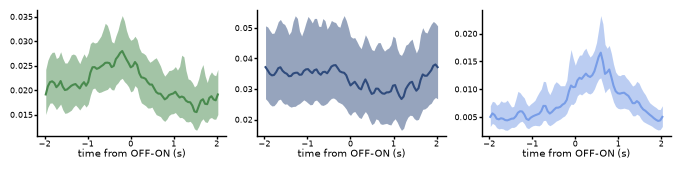

In [58]:
# peth (down)
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4))
for i, e in enumerate(events):
    tc = peth_cat.sel(ev=e,tr='off-on')
    #fma.plotting.semPlot(tc.t,tc.sel(shuf=True).mean(dim='shuf'),polar=True,color=isau.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.t,tc,polar=True,color=isau.paperColors(e),ax=ax[i],smooth=1)
    ax[i].set(xlabel='time from OFF-ON (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'oscill_isa_peth',['png','svg'])

False

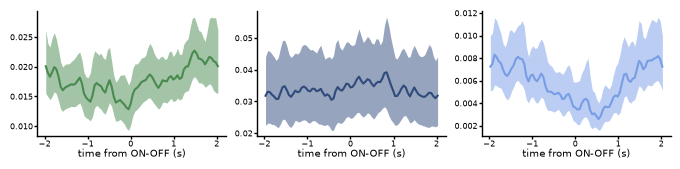

In [59]:
# peth (down)
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4))
for i, e in enumerate(events):
    tc = peth_cat.sel(ev=e,tr='on-off')
    #fma.plotting.semPlot(tc.t,tc.sel(shuf=True).mean(dim='shuf'),polar=True,color=isau.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.t,tc,polar=True,color=isau.paperColors(e),ax=ax[i],smooth=1)
    ax[i].set(xlabel='time from ON-OFF (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'oscill_isa_peth',['png','svg'])

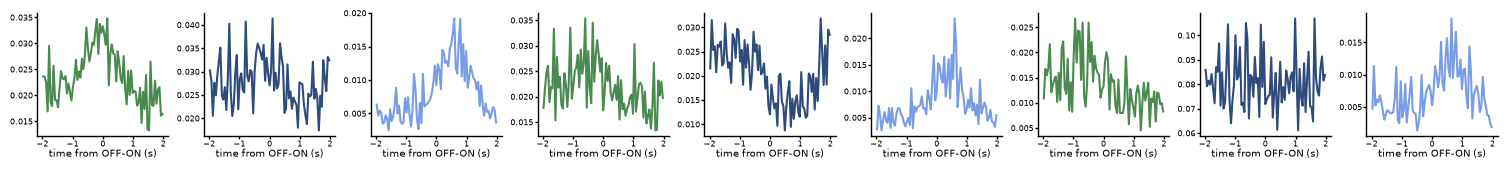

In [60]:
# peth (down)
fig, ax = fma.plotting.makeFigure(n=(1,9),size=(38,4))
for i, e in enumerate(events):
    for j, rat in enumerate(peth_avg.rat.values):
        tc = peth_avg.sel(ev=e,tr='off-on',rat=rat)
        ax[3*j+i].plot(tc.t,tc,color=isau.paperColors(e))
        ax[3*j+i].set(xlabel='time from OFF-ON (s)')

False

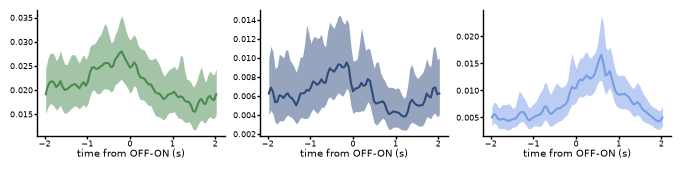

In [53]:
# peth (delta)
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4))
for i, e in enumerate(events):
    tc = peth_cat.sel(ev=e,tr='off-on')
    #fma.plotting.semPlot(tc.t,tc.sel(shuf=True).mean(dim='shuf'),polar=True,color=isau.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.t,tc,polar=True,color=isau.paperColors(e),ax=ax[i],smooth=1)
    ax[i].set(xlabel='time from OFF-ON (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'oscill_isa_peth',['png','svg'])

False

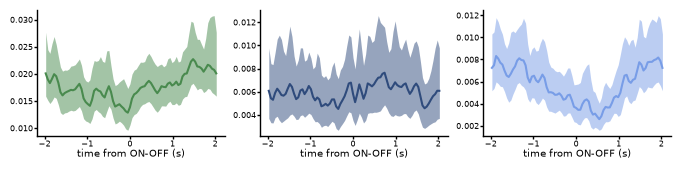

In [54]:
# peth (delta)
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(17,4))
for i, e in enumerate(events):
    tc = peth_cat.sel(ev=e,tr='on-off')
    #fma.plotting.semPlot(tc.t,tc.sel(shuf=True).mean(dim='shuf'),polar=True,color=isau.paperColors('shuffle'),ax=ax[i])
    fma.plotting.semPlot(tc.t,tc,polar=True,color=isau.paperColors(e),ax=ax[i],smooth=1)
    ax[i].set(xlabel='time from ON-OFF (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'oscill_isa_peth',['png','svg'])

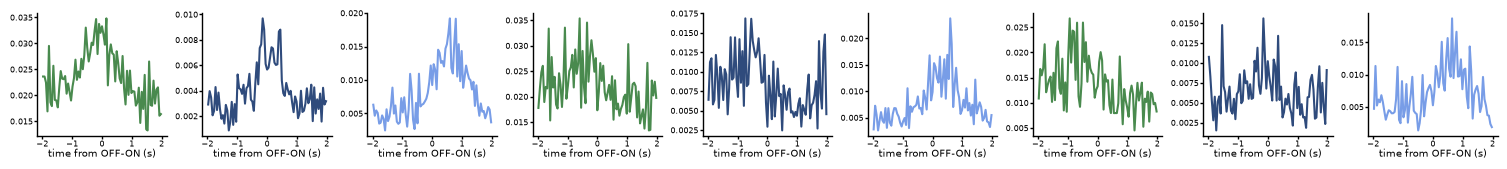

In [55]:
# peth (delta)
fig, ax = fma.plotting.makeFigure(n=(1,9),size=(38,4))
for i, e in enumerate(events):
    for j, rat in enumerate(peth_avg.rat.values):
        tc = peth_avg.sel(ev=e,tr='off-on',rat=rat)
        ax[3*j+i].plot(tc.t,tc,color=isau.paperColors(e))
        ax[3*j+i].set(xlabel='time from OFF-ON (s)')